# 03 — EDA: Insurance Lead Analysis

Deep-dive into lead acquisition profitability using **RPL (Revenue Per Lead)** and **Net/Lead** as primary KPIs.

**Input**: `data/staging/leads_clean.parquet` (from notebook 02)  
**Key constant**: `COST_PER_LEAD = £55`

Sections:
1. Setup & load data
2. Top-line commercial summary
3. Funnel breakdown
4. Dimensional analysis (reusable `analyse_dimension`)
5. Cross-dimensional analysis
6. Zero-sale keyword identification
7. High vs low value profiles
8. Geographic analysis
9. Key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
STAGING_DIR = PROJECT_ROOT / "data" / "staging"

COST_PER_LEAD = 55

# Dark theme
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#0f0f0f",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#cccccc",
    "text.color": "#cccccc",
    "xtick.color": "#999999",
    "ytick.color": "#999999",
    "grid.color": "#222222",
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333333",
    "figure.dpi": 120,
})

# Colour palette
GREEN = "#00c896"
RED = "#ff4d6d"
BLUE = "#4e9af1"
AMBER = "#f0a500"
GREY = "#888888"

In [2]:
leads = pd.read_parquet(STAGING_DIR / "leads_clean.parquet")
print(f"Leads: {leads.shape[0]:,} rows × {leads.shape[1]} cols")
leads.head(3)

Leads: 7,878 rows × 21 cols


,lead_id,lead_status,premium,age,gender,smoker,current_insurance,device_type,keyword,match_type,...,cover_for,verification_status,pc_area,keyword_group,converted,is_invalid,high_value,age_band,created_date,week_start
0,EDC9D129,Contacted,0.0,59,Female,no,no,Smartphone,private medical insurance uk,Exact,...,Self + Partner,not_verified,PE,Generic: Private Health,0,0,0,55-59,2025-01-01,2024-12-30
1,FD26755A,Contacted,0.0,46,Female,no,no,Desktop,bupa cost,Exact,...,Self,not_verified,CV,Brand: Bupa,0,0,0,45-49,2025-01-01,2024-12-30
2,E5CA4886,Contacted,0.0,48,Female,no,no,Smartphone,private health insurance with pre existing con...,Exact,...,Self,not_verified,PE,Pre-existing Conditions,0,0,0,45-49,2025-01-01,2024-12-30


---
## 2. Top-Line Commercial Summary

With `COST_PER_LEAD = £55`, every lead must generate at least £55 in commission revenue to break even.

In [3]:
total_leads = len(leads)
total_sold = leads["converted"].sum()
total_invalid = leads["is_invalid"].sum()
total_premium = leads["premium"].sum()
conv_rate = total_sold / total_leads
invalid_rate = total_invalid / total_leads

total_cost = total_leads * COST_PER_LEAD
rpl = total_premium / total_leads
net_per_lead = rpl - COST_PER_LEAD
total_net = total_premium - total_cost
roi = (total_net / total_cost) * 100

avg_commission = total_premium / total_sold if total_sold > 0 else 0

print("=" * 50)
print("  COMMERCIAL SUMMARY")
print("=" * 50)
print(f"  Total leads:        {total_leads:,}")
print(f"  Conversions (Sold): {total_sold:,}  ({conv_rate:.1%})")
print(f"  Invalid:            {total_invalid:,}  ({invalid_rate:.1%})")
print(f"  Avg commission:     £{avg_commission:,.0f}")
print(f"  ---")
print(f"  Total revenue:      £{total_premium:,.0f}")
print(f"  Total cost:         £{total_cost:,.0f}")
print(f"  Net profit:         £{total_net:,.0f}")
print(f"  ---")
print(f"  RPL:                £{rpl:.2f}")
print(f"  Net / Lead:         £{net_per_lead:.2f}")
print(f"  ROI:                {roi:.1f}%")
print("=" * 50)

  COMMERCIAL SUMMARY
  Total leads:        7,878
  Conversions (Sold): 386  (4.9%)
  Invalid:            342  (4.3%)
  Avg commission:     £1,578
  ---
  Total revenue:      £609,016
  Total cost:         £433,290
  Net profit:         £175,726
  ---
  RPL:                £77.31
  Net / Lead:         £22.31
  ROI:                40.6%


---
## 3. Funnel Breakdown

Where do leads end up in the pipeline?

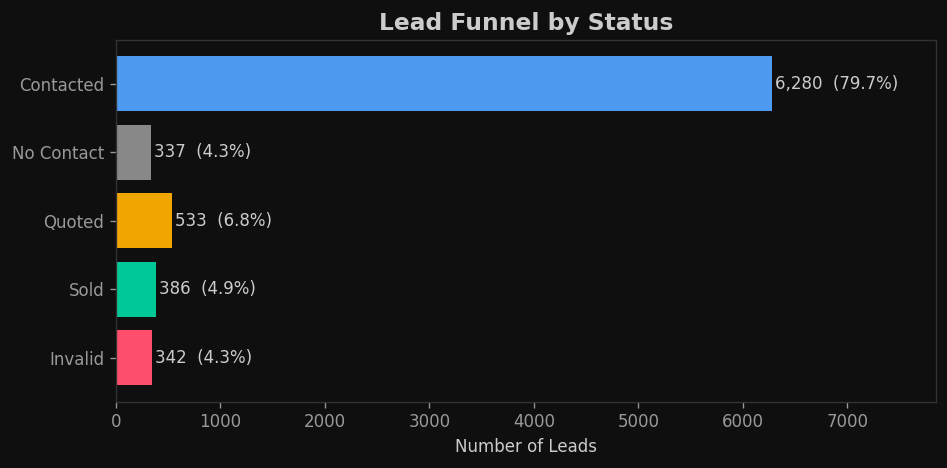

In [4]:
# Funnel by lead status
funnel = (
    leads["lead_status"]
    .value_counts()
    .reindex(["Contacted", "No Contact", "Quoted", "Sold", "Invalid"])
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [BLUE, GREY, AMBER, GREEN, RED]
bars = ax.barh(funnel.index, funnel.values, color=colors)

for bar, val in zip(bars, funnel.values):
    pct = val / total_leads * 100
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10, color="#cccccc")

ax.set_xlabel("Number of Leads")
ax.set_title("Lead Funnel by Status", fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, funnel.max() * 1.25)
plt.tight_layout()
plt.show()

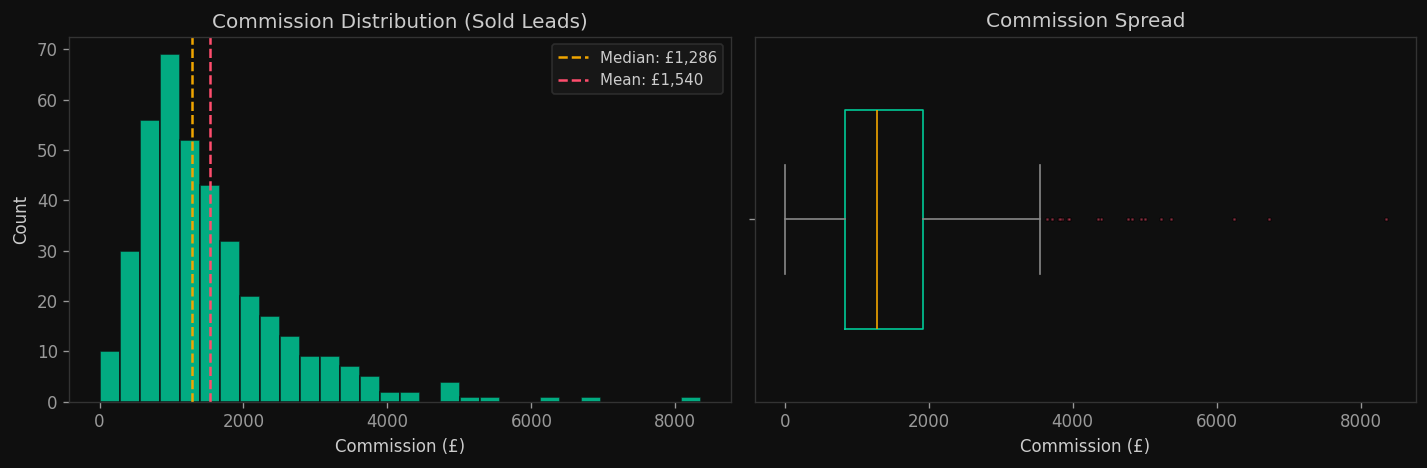

Commission stats: min=£0, median=£1,286, mean=£1,540, max=£8,353


In [5]:
# Commission distribution among converted leads
sold = leads[leads["converted"] == 1]["premium"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(sold, bins=30, color=GREEN, edgecolor="#0f0f0f", alpha=0.85)
axes[0].axvline(sold.median(), color=AMBER, ls="--", label=f"Median: £{sold.median():,.0f}")
axes[0].axvline(sold.mean(), color=RED, ls="--", label=f"Mean: £{sold.mean():,.0f}")
axes[0].set_xlabel("Commission (£)")
axes[0].set_ylabel("Count")
axes[0].set_title("Commission Distribution (Sold Leads)")
axes[0].legend(fontsize=9)

# Box plot
axes[1].boxplot(sold, vert=False, widths=0.6,
                boxprops=dict(color=GREEN), whiskerprops=dict(color=GREY),
                medianprops=dict(color=AMBER), capprops=dict(color=GREY),
                flierprops=dict(marker=".", markerfacecolor=RED, markersize=4, alpha=0.5))
axes[1].set_xlabel("Commission (£)")
axes[1].set_title("Commission Spread")
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

print(f"Commission stats: min=£{sold.min():,.0f}, median=£{sold.median():,.0f}, "
      f"mean=£{sold.mean():,.0f}, max=£{sold.max():,.0f}")

---
## 4. Dimensional Analysis

Reusable `analyse_dimension()` function — prints Leads / Sales / Conv% / RPL / Avg Commission / Invalid% / Net per Lead for each value of any column.

The breakeven line is **£55 RPL**. Anything below that is loss-making.

In [6]:
def analyse_dimension(df, col, cost_per_lead=COST_PER_LEAD, sort_by="rpl"):
    """Analyse any categorical dimension: leads, sales, conversion, RPL, net/lead."""
    summary = (
        df.groupby(col)
        .agg(
            leads=("lead_id", "count"),
            sales=("converted", "sum"),
            invalids=("is_invalid", "sum"),
            revenue=("premium", "sum"),
        )
    )
    summary["conv_%"] = (summary["sales"] / summary["leads"] * 100).round(1)
    summary["invalid_%"] = (summary["invalids"] / summary["leads"] * 100).round(1)
    summary["avg_comm"] = (summary["revenue"] / summary["sales"].replace(0, np.nan)).round(0)
    summary["rpl"] = (summary["revenue"] / summary["leads"]).round(2)
    summary["net_per_lead"] = (summary["rpl"] - cost_per_lead).round(2)
    summary["total_net"] = (summary["net_per_lead"] * summary["leads"]).round(0)

    if sort_by in summary.columns:
        summary = summary.sort_values(sort_by, ascending=False)

    # Format for display
    display_df = summary.copy()
    display_df["avg_comm"] = display_df["avg_comm"].apply(lambda x: f"£{x:,.0f}" if pd.notna(x) else "—")
    display_df["rpl"] = display_df["rpl"].apply(lambda x: f"£{x:,.2f}")
    display_df["net_per_lead"] = display_df["net_per_lead"].apply(lambda x: f"£{x:,.2f}")
    display_df["total_net"] = display_df["total_net"].apply(lambda x: f"£{x:,.0f}")
    display_df["conv_%"] = display_df["conv_%"].apply(lambda x: f"{x:.1f}%")
    display_df["invalid_%"] = display_df["invalid_%"].apply(lambda x: f"{x:.1f}%")

    print(f"\n{'=' * 60}")
    print(f"  Dimension: {col}")
    print(f"{'=' * 60}")
    print(display_df[["leads", "sales", "conv_%", "rpl", "avg_comm", "invalid_%", "net_per_lead", "total_net"]].to_string())

    return summary

In [7]:
# Verification Status — the #1 driver
verification_stats = analyse_dimension(leads, "verification_status")


  Dimension: verification_status
                     leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
verification_status                                                                        
verified              1642    156   9.5%  £135.81   £1,429      1.0%       £80.81  £132,690
not_verified          6236    230   3.7%   £61.90   £1,678      5.2%        £6.90   £43,028


In [8]:
# Device Type
device_stats = analyse_dimension(leads, "device_type")


  Dimension: device_type
             leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
device_type                                                                        
Tablet         330     23   7.0%  £167.40   £2,402      5.8%      £112.40   £37,092
Desktop       1860     93   5.0%  £104.98   £2,100      5.6%       £49.98   £92,963
Smartphone    5688    270   4.7%   £63.03   £1,328      3.8%        £8.03   £45,675


In [9]:
# Current Insurance
insurance_stats = analyse_dimension(leads, "current_insurance")


  Dimension: current_insurance
                   leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
current_insurance                                                                        
yes private          999     80   8.0%  £167.94   £2,097      4.7%      £112.94  £112,827
yes company          413     21   5.1%  £128.27   £2,523      5.6%       £73.27   £30,261
no                  6466    285   4.4%   £60.05   £1,362      4.2%        £5.05   £32,653


In [10]:
# Keyword Group
keyword_stats = analyse_dimension(leads, "keyword_group")


  Dimension: keyword_group
                           leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
keyword_group                                                                                    
Brand: Other                  95     11  11.6%  £236.64   £2,044      2.1%      £181.64   £17,256
Generic: Health Insurance   1009     59   5.8%   £86.10   £1,472      4.5%       £31.10   £31,380
Comparison / Research        433     12   2.8%   £82.95   £2,993      6.7%       £27.95   £12,102
Price / Quote Intent         467     18   3.9%   £81.91   £2,125      3.6%       £26.91   £12,567
Generic: Private Health     3510    187   5.3%   £77.64   £1,457      4.1%       £22.64   £79,466
Brand: Bupa                 1695     83   4.9%   £77.20   £1,577      4.1%       £22.20   £37,629
Pre-existing Conditions      485     12   2.5%   £34.61   £1,399      5.8%      £-20.39   £-9,889
Other                        184      4   2.2%   £29.04   £1,336      3.8%      £-25.96   

In [11]:
# Cover For
cover_stats = analyse_dimension(leads, "cover_for")


  Dimension: cover_for
                leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
cover_for                                                                             
Self + Partner   1459     64   4.4%  £106.86   £2,436      4.7%       £51.86   £75,664
Self + Family    1948    116   6.0%   £93.69   £1,573      3.8%       £38.69   £75,368
Self             4471    206   4.6%   £60.52   £1,314      4.5%        £5.52   £24,680


In [12]:
# Age Band
age_stats = analyse_dimension(leads, "age_band", sort_by="leads")


  Dimension: age_band
          leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
age_band                                                                        
35-39      1089     53   4.9%   £62.84   £1,291      4.2%        £7.84    £8,538
40-44      1024     52   5.1%   £74.48   £1,467      4.8%       £19.48   £19,948
45-49       776     39   5.0%   £73.45   £1,461      3.9%       £18.45   £14,317
65-74       740     33   4.5%  £131.26   £2,943      3.6%       £76.26   £56,432
50-54       712     35   4.9%   £71.44   £1,453      5.9%       £16.44   £11,705
30-34       665     32   4.8%   £48.34   £1,005      3.2%       £-6.66   £-4,429
55-59       639     41   6.4%  £113.57   £1,770      4.7%       £58.57   £37,426
25-29       634     31   4.9%   £42.03     £860      4.7%      £-12.97   £-8,223
60-64       551     29   5.3%   £97.36   £1,850      4.4%       £42.36   £23,340
Under 25    546     20   3.7%   £25.23     £689      4.9%      £-29.77  £-16,254
75+  

/var/folders/7k/007gkgf90hn56gqpkdw63_v40000gn/T/ipykernel_21573/3918990177.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)


In [13]:
# Match Type
match_stats = analyse_dimension(leads, "match_type")


  Dimension: match_type
            leads  sales conv_%     rpl avg_comm invalid_% net_per_lead total_net
match_type                                                                       
Phrase       1415     86   6.1%  £97.58   £1,606      4.5%       £42.58   £60,251
Exact        5085    260   5.1%  £76.14   £1,489      4.0%       £21.14  £107,497
Broad        1359     39   2.9%  £60.82   £2,120      5.3%        £5.82    £7,909


In [14]:
# Gender
gender_stats = analyse_dimension(leads, "gender")


  Dimension: gender
        leads  sales conv_%     rpl avg_comm invalid_% net_per_lead total_net
gender                                                                       
Male     3666    182   5.0%  £79.89   £1,609      5.3%       £24.89   £91,247
Female   4212    204   4.8%  £75.06   £1,550      3.5%       £20.06   £84,493


In [15]:
# Smoker
smoker_stats = analyse_dimension(leads, "smoker")


  Dimension: smoker
        leads  sales conv_%     rpl avg_comm invalid_% net_per_lead total_net
smoker                                                                       
no       7156    353   4.9%  £78.46   £1,590      4.4%       £23.46  £167,880
yes       722     33   4.6%  £65.90   £1,442      3.6%       £10.90    £7,870


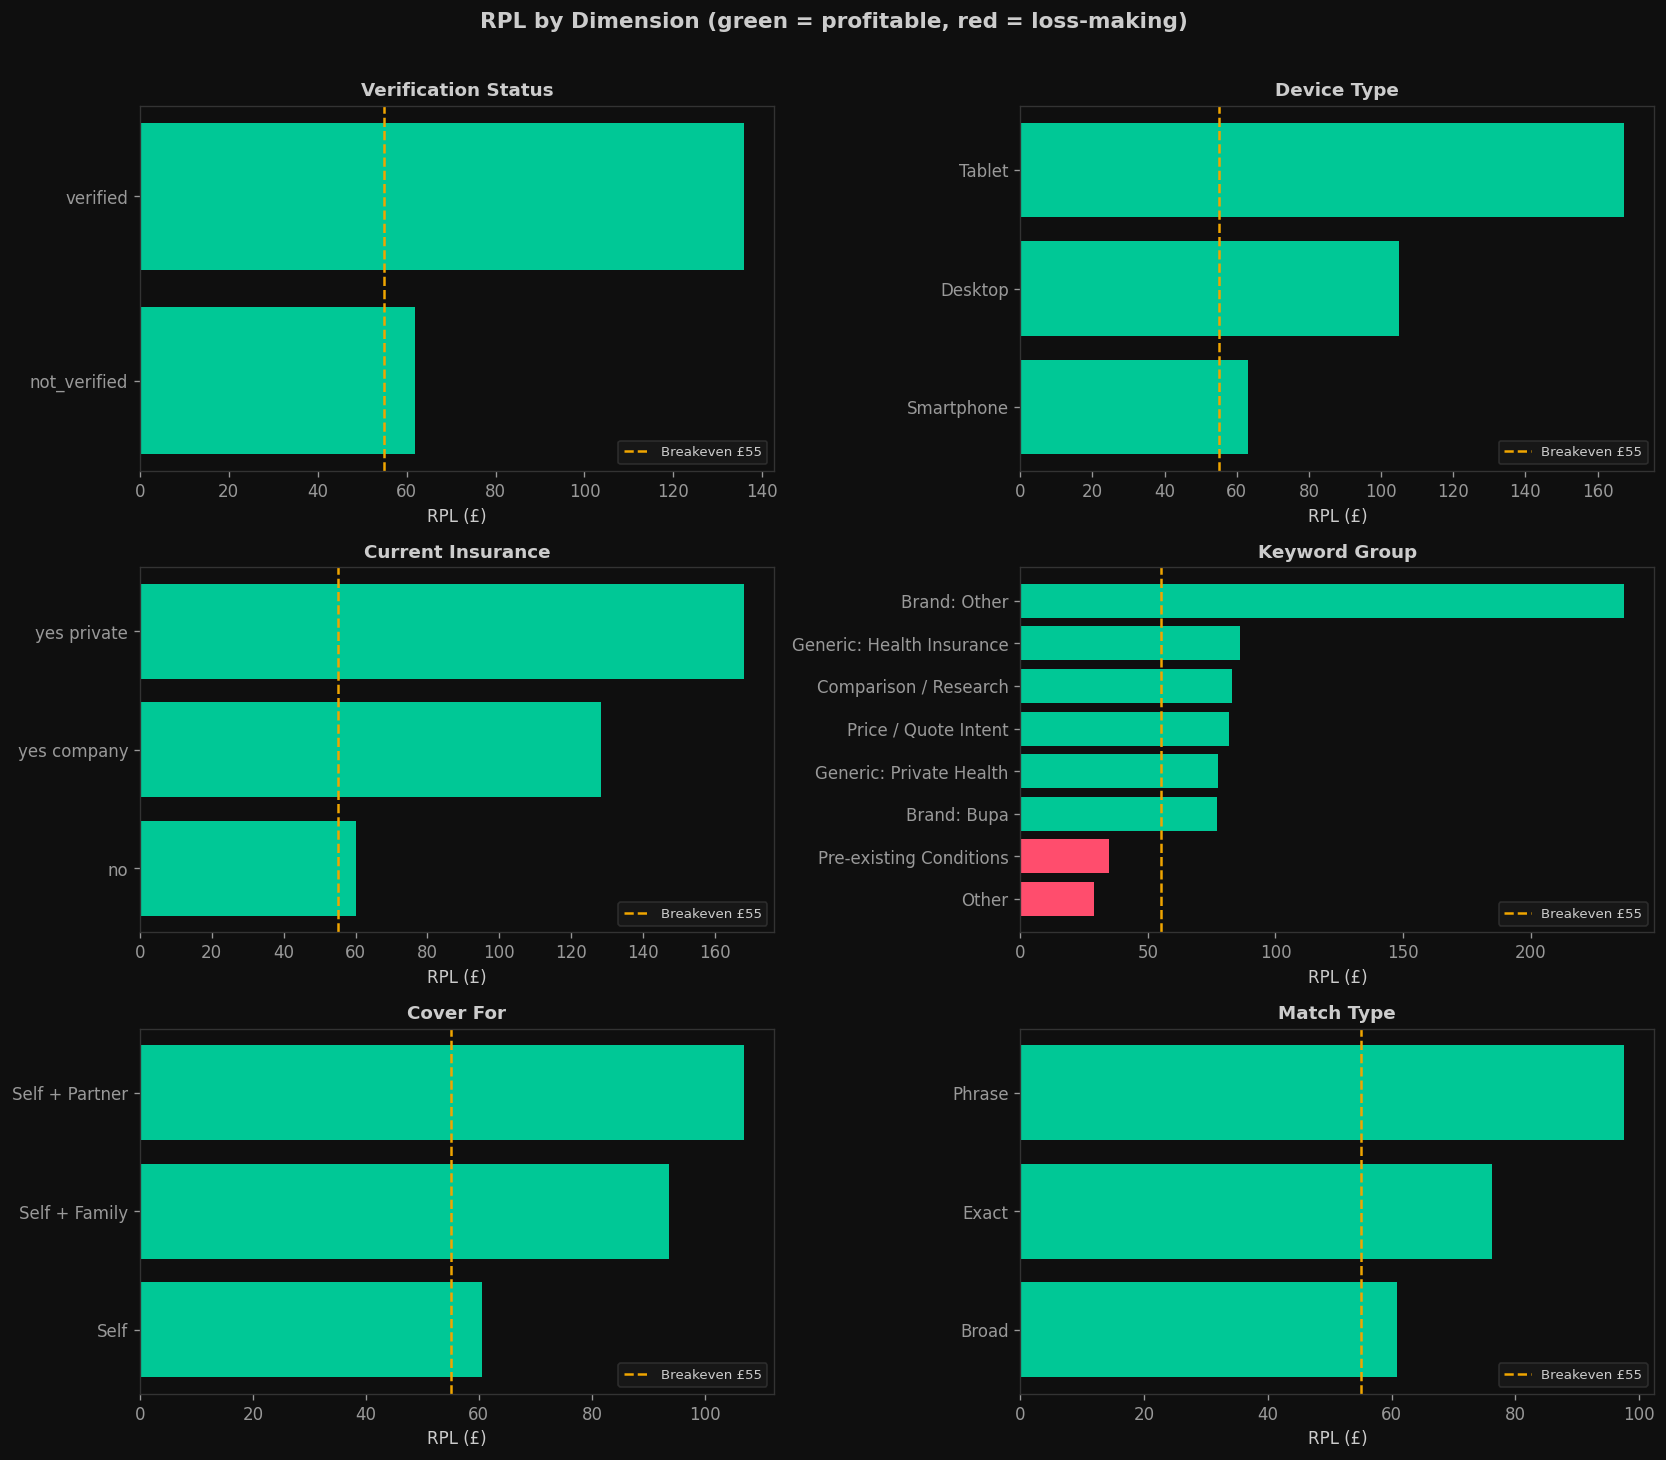

In [16]:
# Visual comparison — RPL by dimension (top dimensions)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

def plot_rpl_bars(ax, stats, title):
    """Bar chart of RPL with breakeven line."""
    vals = stats.sort_values("rpl", ascending=True)
    colors_list = [GREEN if v >= COST_PER_LEAD else RED for v in vals["rpl"]]
    bars = ax.barh(vals.index.astype(str), vals["rpl"], color=colors_list)
    ax.axvline(COST_PER_LEAD, color=AMBER, ls="--", lw=1.5, label=f"Breakeven £{COST_PER_LEAD}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("RPL (£)")
    ax.legend(fontsize=8, loc="lower right")

plot_rpl_bars(axes[0, 0], verification_stats, "Verification Status")
plot_rpl_bars(axes[0, 1], device_stats, "Device Type")
plot_rpl_bars(axes[1, 0], insurance_stats, "Current Insurance")
plot_rpl_bars(axes[1, 1], keyword_stats, "Keyword Group")
plot_rpl_bars(axes[2, 0], cover_stats, "Cover For")
plot_rpl_bars(axes[2, 1], match_stats, "Match Type")

plt.suptitle("RPL by Dimension (green = profitable, red = loss-making)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Cross-Dimensional Analysis

Signals stack multiplicatively. A verified + tablet lead is worth far more than an unverified + smartphone lead.

Verification × Device Type
                                 leads  sales  conv_%     rpl  net_per_lead
verification_status device_type                                            
not_verified        Desktop       1564     62     4.0   82.24         27.24
                    Smartphone    4385    152     3.5   49.43         -5.57
                    Tablet         287     16     5.6  141.60         86.60
verified            Desktop        296     31    10.5  225.14        170.14
                    Smartphone    1303    118     9.1  108.79         53.79
                    Tablet          43      7    16.3  339.54        284.54


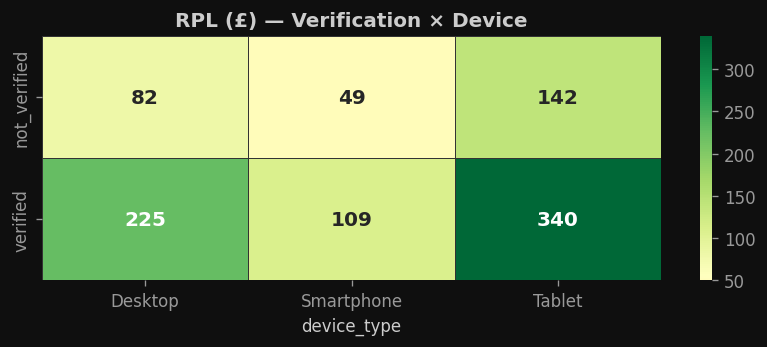

In [17]:
# Verification × Device Type
cross_vd = (
    leads.groupby(["verification_status", "device_type"])
    .agg(leads=("lead_id", "count"), sales=("converted", "sum"), revenue=("premium", "sum"))
)
cross_vd["conv_%"] = (cross_vd["sales"] / cross_vd["leads"] * 100).round(1)
cross_vd["rpl"] = (cross_vd["revenue"] / cross_vd["leads"]).round(2)
cross_vd["net_per_lead"] = (cross_vd["rpl"] - COST_PER_LEAD).round(2)

print("Verification × Device Type")
print(cross_vd[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())

# Heatmap — RPL
pivot_rpl = cross_vd["rpl"].unstack(level="device_type")
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot_rpl, annot=True, fmt=".0f", cmap="RdYlGn", center=COST_PER_LEAD,
            linewidths=0.5, linecolor="#333333", ax=ax,
            annot_kws={"fontsize": 12, "fontweight": "bold"})
ax.set_title("RPL (£) — Verification × Device", fontsize=12, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Verification × Current Insurance
                                       leads  sales  conv_%     rpl  net_per_lead
verification_status current_insurance                                            
not_verified        no                  5085    165     3.2   46.18         -8.82
                    yes company          318     10     3.1   66.75         11.75
                    yes private          833     55     6.6  156.05        101.05
verified            no                  1381    120     8.7  111.12         56.12
                    yes company           95     11    11.6  334.20        279.20
                    yes private          166     25    15.1  227.66        172.66


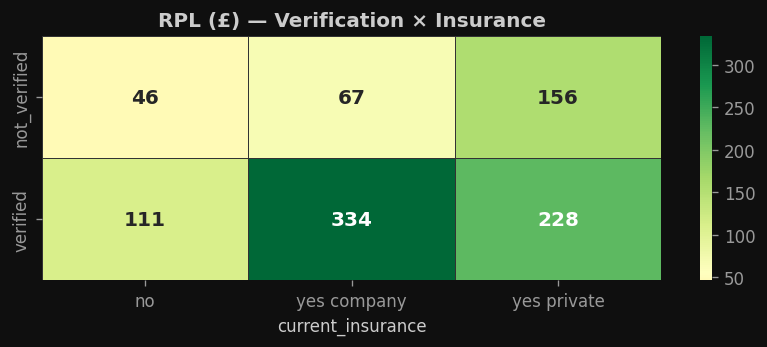

In [18]:
# Verification × Current Insurance
cross_vi = (
    leads.groupby(["verification_status", "current_insurance"])
    .agg(leads=("lead_id", "count"), sales=("converted", "sum"), revenue=("premium", "sum"))
)
cross_vi["conv_%"] = (cross_vi["sales"] / cross_vi["leads"] * 100).round(1)
cross_vi["rpl"] = (cross_vi["revenue"] / cross_vi["leads"]).round(2)
cross_vi["net_per_lead"] = (cross_vi["rpl"] - COST_PER_LEAD).round(2)

print("Verification × Current Insurance")
print(cross_vi[["leads", "sales", "conv_%", "rpl", "net_per_lead"]].to_string())

# Heatmap — RPL
pivot_vi = cross_vi["rpl"].unstack(level="current_insurance")
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot_vi, annot=True, fmt=".0f", cmap="RdYlGn", center=COST_PER_LEAD,
            linewidths=0.5, linecolor="#333333", ax=ax,
            annot_kws={"fontsize": 12, "fontweight": "bold"})
ax.set_title("RPL (£) — Verification × Insurance", fontsize=12, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

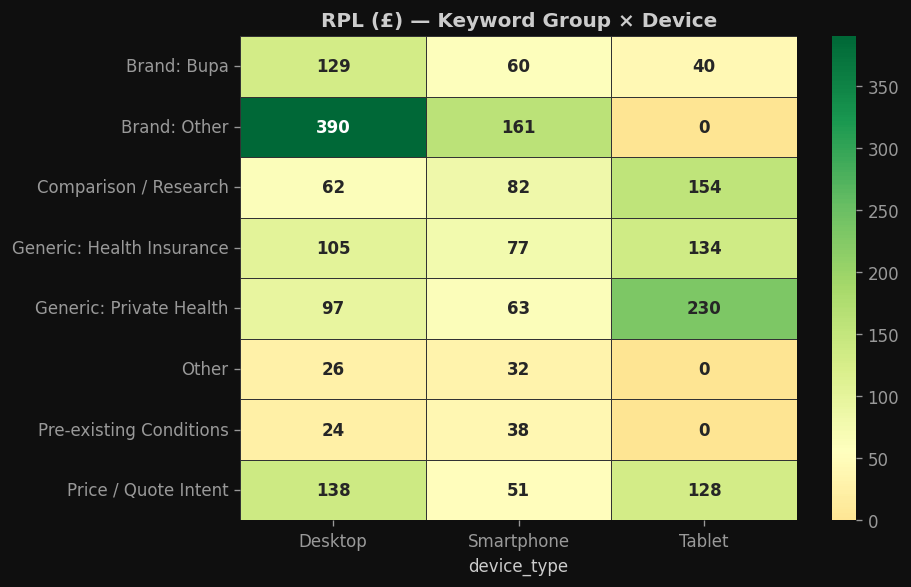

In [19]:
# Keyword Group × Device Type
cross_kd = (
    leads.groupby(["keyword_group", "device_type"])
    .agg(leads=("lead_id", "count"), sales=("converted", "sum"), revenue=("premium", "sum"))
)
cross_kd["rpl"] = (cross_kd["revenue"] / cross_kd["leads"]).round(2)

pivot_kd = cross_kd["rpl"].unstack(level="device_type").fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_kd, annot=True, fmt=".0f", cmap="RdYlGn", center=COST_PER_LEAD,
            linewidths=0.5, linecolor="#333333", ax=ax,
            annot_kws={"fontsize": 10, "fontweight": "bold"})
ax.set_title("RPL (£) — Keyword Group × Device", fontsize=12, fontweight="bold")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 6. Zero-Sale Keywords

Identify individual keywords with a meaningful volume of leads but zero conversions — these are pure waste at £55/lead.

In [20]:
# Keywords with ≥15 leads and zero sales
kw_perf = (
    leads.groupby("keyword")
    .agg(leads=("lead_id", "count"), sales=("converted", "sum"), revenue=("premium", "sum"))
    .reset_index()
)

zero_sale = kw_perf[(kw_perf["leads"] >= 15) & (kw_perf["sales"] == 0)].copy()
zero_sale["wasted_spend"] = zero_sale["leads"] * COST_PER_LEAD
zero_sale = zero_sale.sort_values("leads", ascending=False)

print(f"Keywords with ≥15 leads and 0 sales: {len(zero_sale)}")
print(f"Total wasted leads: {zero_sale['leads'].sum():,}")
print(f"Total wasted spend: £{zero_sale['wasted_spend'].sum():,}")
print()
print(zero_sale[["keyword", "leads", "wasted_spend"]].to_string(index=False))

Keywords with ≥15 leads and 0 sales: 11
Total wasted leads: 297
Total wasted spend: £16,335

                                           keyword  leads  wasted_spend
                  private medical insurance policy     68          3740
health insurance for people with pre existing cond     45          2475
                          medical shield insurance     40          2200
      health insurance for pre existing conditions     26          1430
 private medical insurance for existing conditions     19          1045
      insurance for undiagnosed medical conditions     18           990
         medical insurance pre existing conditions     18           990
                       '+health +insurance +policy     16           880
health insurance that covers pre existing conditio     16           880
 health insurance to cover pre existing conditions     16           880
                         health insurance plans uk     15           825


---
## 7. High vs Low Value Profiles

Compare the top 25% performing segments (by RPL) to the bottom 25% across all dimensions.

In [21]:
# Per-lead RPL by key dimensions
lead_profile = leads.copy()
lead_profile["lead_revenue"] = lead_profile["premium"]  # commission per lead (0 if not sold)

# Group by composite profile
profile_cols = ["verification_status", "device_type", "current_insurance"]
profile_stats = (
    lead_profile.groupby(profile_cols)
    .agg(leads=("lead_id", "count"), revenue=("lead_revenue", "sum"), sales=("converted", "sum"))
)
profile_stats["rpl"] = (profile_stats["revenue"] / profile_stats["leads"]).round(2)
profile_stats["conv_%"] = (profile_stats["sales"] / profile_stats["leads"] * 100).round(1)
profile_stats = profile_stats.sort_values("rpl", ascending=False)

# Top 25% and bottom 25% by RPL
n = len(profile_stats)
q25 = max(1, n // 4)
top_profiles = profile_stats.head(q25)
bottom_profiles = profile_stats.tail(q25)

print("=" * 60)
print("  TOP PROFILES (highest RPL)")
print("=" * 60)
print(top_profiles[["leads", "sales", "conv_%", "rpl"]].to_string())

print(f"\n{'=' * 60}")
print("  BOTTOM PROFILES (lowest RPL)")
print("=" * 60)
print(bottom_profiles[["leads", "sales", "conv_%", "rpl"]].to_string())

  TOP PROFILES (highest RPL)
                                                   leads  sales  conv_%      rpl
verification_status device_type current_insurance                               
verified            Tablet      yes company            2      1    50.0  1274.52
                    Desktop     yes company           31      6    19.4   641.10
not_verified        Tablet      yes private           57      8    14.0   472.85
verified            Desktop     yes private           48      9    18.8   367.86

  BOTTOM PROFILES (lowest RPL)
                                                   leads  sales  conv_%    rpl
verification_status device_type current_insurance                             
not_verified        Desktop     no                  1126     33     2.9  52.92
                    Smartphone  no                  3734    125     3.3  43.48
                                yes company          169      4     2.4  36.26
verified            Tablet      yes private            7  

In [22]:
# Worst segment quantification: unverified + no insurance + smartphone
worst_mask = (
    (leads["verification_status"] == "not_verified") &
    (leads["current_insurance"] == "no") &
    (leads["device_type"] == "Smartphone")
)
worst = leads[worst_mask]
worst_n = len(worst)
worst_sales = worst["converted"].sum()
worst_rev = worst["premium"].sum()
worst_cost = worst_n * COST_PER_LEAD
worst_net = worst_rev - worst_cost

print(f"Worst segment: Unverified + No Insurance + Smartphone")
print(f"  Leads:      {worst_n:,} ({worst_n / total_leads:.1%} of all leads)")
print(f"  Sales:      {worst_sales}")
print(f"  Revenue:    £{worst_rev:,.0f}")
print(f"  Cost:       £{worst_cost:,.0f}")
print(f"  Net:        £{worst_net:,.0f}")
print(f"  RPL:        £{worst_rev / worst_n:.2f}")
print(f"  Conv rate:  {worst_sales / worst_n:.2%}")

Worst segment: Unverified + No Insurance + Smartphone
  Leads:      3,734 (47.4% of all leads)
  Sales:      125
  Revenue:    £162,369
  Cost:       £205,370
  Net:        £-43,001
  RPL:        £43.48
  Conv rate:  3.35%


---
## 8. Geographic Analysis

Top-level postcode areas (PC_Area) — are there geographic patterns in RPL?


  Dimension: pc_area
         leads  sales conv_%      rpl avg_comm invalid_% net_per_lead total_net
pc_area                                                                        
LD           3      1  33.3%  £540.72   £1,622      0.0%      £485.72    £1,457
CB          54      6  11.1%  £269.75   £2,428      9.3%      £214.75   £11,596
SN          71      6   8.5%  £262.89   £3,111      4.2%      £207.89   £14,760
WD          28      3  10.7%  £260.39   £2,430      7.1%      £205.39    £5,751
HR          23      4  17.4%  £188.95   £1,086      4.3%      £133.95    £3,081
EN          50      3   6.0%  £186.06   £3,101      0.0%      £131.06    £6,553
RG         116      9   7.8%  £185.93   £2,396      4.3%      £130.93   £15,188
GU          89      8   9.0%  £185.88   £2,068      2.2%      £130.88   £11,648
SG          61      4   6.6%  £181.94   £2,775      3.3%      £126.94    £7,743
WV          55      6  10.9%  £179.03   £1,641      3.6%      £124.03    £6,822
WN          38    

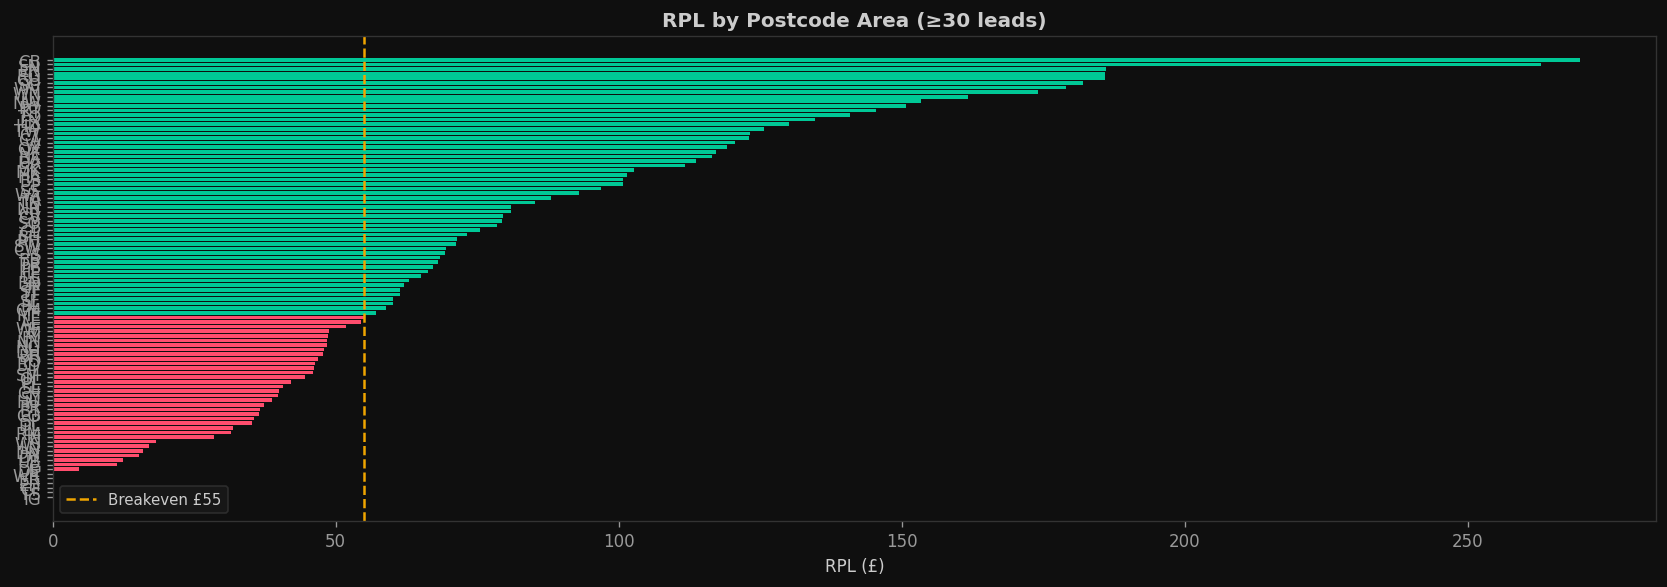


Areas above breakeven: 56 / 96
Areas below breakeven: 40 / 96


In [23]:
# PC Area analysis (only areas with ≥30 leads for reliability)
geo_stats = analyse_dimension(leads, "pc_area")
geo_stats = geo_stats[geo_stats["leads"] >= 30].copy()

fig, ax = plt.subplots(figsize=(14, 5))
geo_sorted = geo_stats.sort_values("rpl", ascending=True)
colors_list = [GREEN if v >= COST_PER_LEAD else RED for v in geo_sorted["rpl"]]
ax.barh(geo_sorted.index.astype(str), geo_sorted["rpl"], color=colors_list)
ax.axvline(COST_PER_LEAD, color=AMBER, ls="--", lw=1.5, label=f"Breakeven £{COST_PER_LEAD}")
ax.set_xlabel("RPL (£)")
ax.set_title("RPL by Postcode Area (≥30 leads)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nAreas above breakeven: {(geo_sorted['rpl'] >= COST_PER_LEAD).sum()} / {len(geo_sorted)}")
print(f"Areas below breakeven: {(geo_sorted['rpl'] < COST_PER_LEAD).sum()} / {len(geo_sorted)}")

---
## 9. Time Trends

Weekly lead volume, conversion rate, and RPL over time.

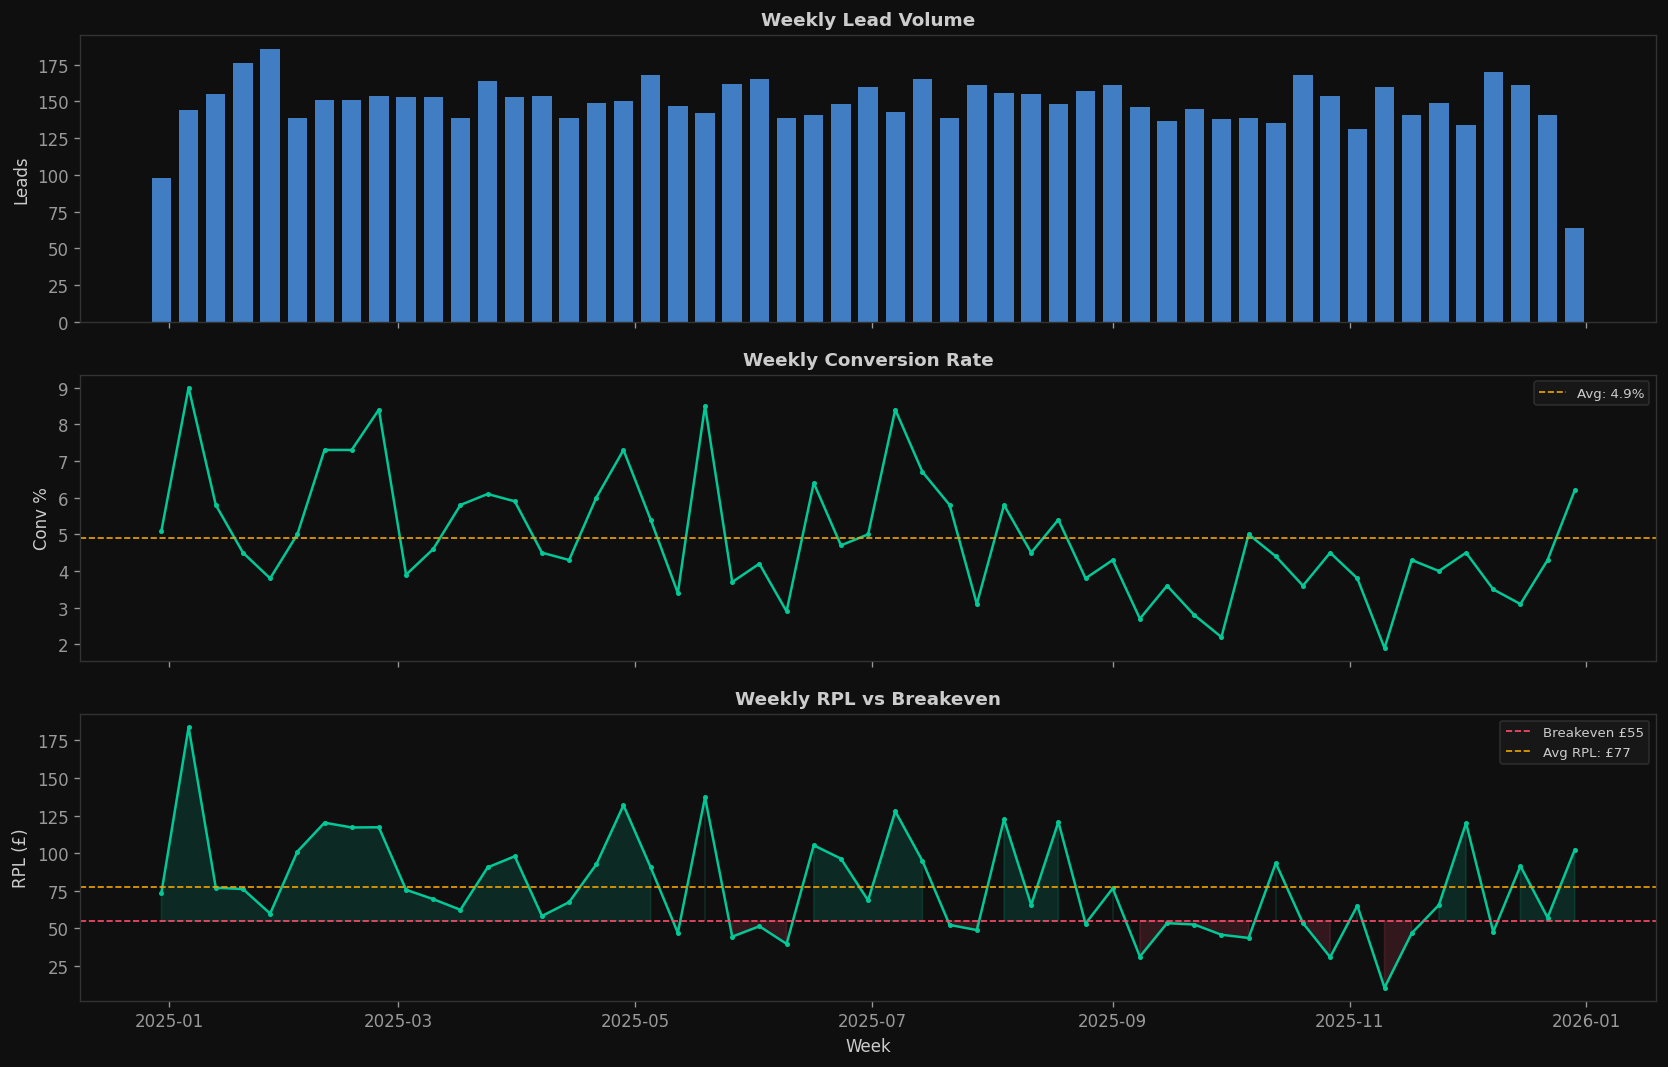

In [24]:
# Weekly trends
weekly = (
    leads.groupby("week_start")
    .agg(leads=("lead_id", "count"), sales=("converted", "sum"), revenue=("premium", "sum"))
)
weekly["conv_%"] = (weekly["sales"] / weekly["leads"] * 100).round(1)
weekly["rpl"] = (weekly["revenue"] / weekly["leads"]).round(2)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Lead volume
axes[0].bar(weekly.index, weekly["leads"], color=BLUE, width=5, alpha=0.8)
axes[0].set_ylabel("Leads")
axes[0].set_title("Weekly Lead Volume", fontsize=11, fontweight="bold")

# Conversion rate
axes[1].plot(weekly.index, weekly["conv_%"], color=GREEN, marker=".", markersize=4, lw=1.5)
axes[1].axhline(conv_rate * 100, color=AMBER, ls="--", lw=1, label=f"Avg: {conv_rate:.1%}")
axes[1].set_ylabel("Conv %")
axes[1].set_title("Weekly Conversion Rate", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=8)

# RPL
axes[2].plot(weekly.index, weekly["rpl"], color=GREEN, marker=".", markersize=4, lw=1.5)
axes[2].axhline(COST_PER_LEAD, color=RED, ls="--", lw=1, label=f"Breakeven £{COST_PER_LEAD}")
axes[2].axhline(rpl, color=AMBER, ls="--", lw=1, label=f"Avg RPL: £{rpl:.0f}")
axes[2].fill_between(weekly.index, COST_PER_LEAD, weekly["rpl"],
                     where=weekly["rpl"] >= COST_PER_LEAD, alpha=0.15, color=GREEN)
axes[2].fill_between(weekly.index, COST_PER_LEAD, weekly["rpl"],
                     where=weekly["rpl"] < COST_PER_LEAD, alpha=0.15, color=RED)
axes[2].set_ylabel("RPL (£)")
axes[2].set_xlabel("Week")
axes[2].set_title("Weekly RPL vs Breakeven", fontsize=11, fontweight="bold")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. Key Findings Summary

In [25]:
print("""
KEY FINDINGS
============

1. OVERALL PROFITABILITY
   - RPL: £{rpl:.2f} vs breakeven £{cpl} → Net/Lead: £{net:.2f}
   - Total net profit: £{total_net:,.0f} on {n:,} leads

2. VERIFICATION IS THE #1 DRIVER
   - Verified leads convert at much higher rates with higher RPL
   - Unverified leads dominate volume but drag down profitability

3. DEVICE TYPE MATTERS
   - Tablet users are highest value despite lowest volume
   - Smartphone is highest volume but lowest RPL

4. WORST SEGMENT (Unverified + No Insurance + Smartphone)
   - {worst_pct:.1f}% of all leads
   - Loss-making: RPL £{worst_rpl:.2f} vs £{cpl} breakeven

5. ZERO-SALE KEYWORDS
   - {zero_n} keywords with ≥15 leads and zero conversions
   - £{zero_waste:,} wasted spend — candidates for pausing

6. SIGNALS STACK MULTIPLICATIVELY
   - Cross-dimensional analysis shows combined effects
   - Best combo: verified + tablet + has insurance
   - Worst combo: unverified + smartphone + no insurance
""".format(
    rpl=rpl, cpl=COST_PER_LEAD, net=net_per_lead, total_net=total_net, n=total_leads,
    worst_pct=worst_n / total_leads * 100, worst_rpl=worst_rev / worst_n,
    zero_n=len(zero_sale), zero_waste=int(zero_sale["wasted_spend"].sum()),
))


KEY FINDINGS

1. OVERALL PROFITABILITY
   - RPL: £77.31 vs breakeven £55 → Net/Lead: £22.31
   - Total net profit: £175,726 on 7,878 leads

2. VERIFICATION IS THE #1 DRIVER
   - Verified leads convert at much higher rates with higher RPL
   - Unverified leads dominate volume but drag down profitability

3. DEVICE TYPE MATTERS
   - Tablet users are highest value despite lowest volume
   - Smartphone is highest volume but lowest RPL

4. WORST SEGMENT (Unverified + No Insurance + Smartphone)
   - 47.4% of all leads
   - Loss-making: RPL £43.48 vs £55 breakeven

5. ZERO-SALE KEYWORDS
   - 11 keywords with ≥15 leads and zero conversions
   - £16,335 wasted spend — candidates for pausing

6. SIGNALS STACK MULTIPLICATIVELY
   - Cross-dimensional analysis shows combined effects
   - Best combo: verified + tablet + has insurance
   - Worst combo: unverified + smartphone + no insurance

